In [1]:
from __future__ import annotations

import operator
from pathlib import Path
from typing import TypedDict, List, Annotated, Literal

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

In [3]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ..., description = "One sentence describing what the reader should be able to do/ understand after this section.",
    )
    bullets: List[str] = Field(
        min_length = 3, 
        max_length = 5, 
        description = "3-5 concrete, non-overlapping subpoints to cover in this section."
    )
    target_words: int = Field(
        ..., 
        description = "Target word count for this section (120-450).",
    )
    section_type: Literal[
        "intro", "core","example", "Checklist", "common_mistake", "conclusion"
    ] = Field(
        ...,
        description = "Use 'common_mistakes' exactly one in the plan."
    )

In [4]:
class Plan(BaseModel):
    blog_title: str
    audience: str = Field(..., description= "Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    tasks: List[Task]

In [5]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add] #reducer concatenates worker outputs
    final: str

In [6]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [7]:
def orchestrator(state: State) -> dict:
    planner = llm.with_structured_output(Plan)

    plan = planner.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Your job is to produce a "
                    "highly actionable outline for a technical blog post.\n\n"
                    "Hard requirements:\n"
                    "- Create 5–7 sections (tasks) that fit a technical blog.\n"
                    "- Each section must include:\n"
                    "  1) goal (1 sentence: what the reader can do/understand after the section)\n"
                    "  2) 3–5 bullets that are concrete, specific, and non-overlapping\n"
                    "  3) target word count (120–450)\n"
                    "- Include EXACTLY ONE section with section_type='common_mistakes'.\n\n"
                    "Make it technical (not generic):\n"
                    "- Assume the reader is a developer; use correct terminology.\n"
                    "- Prefer design/engineering structure: problem → intuition → approach → implementation → "
                    "trade-offs → testing/observability → conclusion.\n"
                    "- Bullets must be actionable and testable (e.g., 'Show a minimal code snippet for X', "
                    "'Explain why Y fails under Z condition', 'Add a checklist for production readiness').\n"
                    "- Explicitly include at least ONE of the following somewhere in the plan (as bullets):\n"
                    "  * a minimal working example (MWE) or code sketch\n"
                    "  * edge cases / failure modes\n"
                    "  * performance/cost considerations\n"
                    "  * security/privacy considerations (if relevant)\n"
                    "  * debugging tips / observability (logs, metrics, traces)\n"
                    "- Avoid vague bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what "
                    "to build/compare/measure/verify.\n\n"
                    "Ordering guidance:\n"
                    "- Start with a crisp intro and problem framing.\n"
                    "- Build core concepts before advanced details.\n"
                    "- Include one section for common mistakes and how to avoid them.\n"
                    "- End with a practical summary/checklist and next steps.\n\n"
                    "Output must strictly match the Plan schema."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )

    return {"plan": plan}

In [8]:
def fanout(state:State):
    return [
        Send(
            "worker",
            {"task": task, "topic": state["topic"], "plan": state["plan"]},
        )
        for task in state["plan"].tasks
    ]

In [9]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md = llm.invoke(
        [
            SystemMessage(
    content=(
        "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
        "Hard constraints:\n"
        "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
        "- Stay close to the Target words (±15%).\n"
        "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"
    )
)
,
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Section type: {task.section_type}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets:{bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [10]:
import re

def safe_filename(title: str) -> str:
    # remove/replace characters invalid in Windows filenames: \ / : * ? " < > |
    name = re.sub(r'[\\/:*?"<>|]', '', title)
    name = re.sub(r'\s+', '_', name.strip())
    return name.lower() + ".md"

In [11]:
def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    final_md = f"# {title}\n\n{body}\n"

    filename = safe_filename(title)
    output_path = Path(filename)

    print("CWD:", Path.cwd())
    print("Writing to:", output_path.resolve())
    try:
        output_path.write_text(final_md, encoding="utf-8")
        print("Write succeeded. Exists:", output_path.exists())
    except Exception as e:
        print("WRITE FAILED:", repr(e))

    return {"final": final_md}

In [12]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer",END)

app = g.compile()

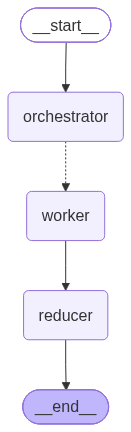

In [13]:
app

In [14]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

CWD: d:\LangGraph\AI_agent_plans
Writing to: D:\LangGraph\AI_agent_plans\mastering_self-attention_from_fundamentals_to_implementation.md
Write succeeded. Exists: True


In [15]:
from rich import print
print(out)

{
    'topic': 'Write a blog on Self Attention',
    'plan': Plan(
        blog_title='Mastering Self-Attention: From Fundamentals to Implementation',
        audience='Software developers and engineers interested in deep learning and natural language processing',
        tone='Practical and technical',
        tasks=[
            Task(
                id=1,
                title='Introduction to Self-Attention and Its Importance',
                goal='Understand what self-attention is and why it is pivotal in modern deep learning architectures
like transformers.',
                bullets=[
                    'Define self-attention and contrast it with traditional attention mechanisms.',
                    'Explain the role of self-attention in capturing dependencies within sequences without 
recurrent or convolutional operations.',
                    'Illustrate typical applications such as in NLP, speech processing, and vision tasks.',
                    'Summarize how self-attention overcomes limitations of RNNs and CNNs in sequence modeling.',
                    'Outline the computational complexity and parallelism advantages that make self-attention 
scalable.'
                ],
                target_words=300,
                section_type='intro'
            ),
            Task(
                id=2,
                title='Core Concepts Underlying Self-Attention',
                goal='Build an in-depth understanding of the mathematical and algorithmic foundations of 
self-attention mechanisms.',
                bullets=[
                    'Decompose self-attention into its key components: queries, keys, and values (QKV) with 
corresponding dimensions.',
                    'Mathematically express the scaled dot-product attention formula and explain the role of 
softmax in weighting.',
                    'Describe the intuition behind key-query matching to compute attention scores.',
                    "Discuss positional encoding and why it's necessary given self-attention’s permutation 
invariance.",
                    'Demonstrate with pseudo-code the flow of input embeddings through QKV projections and 
attention calculation.'
                ],
                target_words=400,
                section_type='core'
            ),
            Task(
                id=3,
                title='Implementing a Minimal Working Example of Self-Attention',
                goal='Write and understand a concise implementation of self-attention from scratch in Python using 
NumPy or PyTorch.',
                bullets=[
                    'Provide a complete minimal working example (MWE) of scaled dot-product self-attention on a 
batch of input embeddings.',
                    'Explain tensor shapes and broadcasting rules used throughout the implementation.',
                    'Test the implementation with a small synthetic example and verify output shapes and values.',
                    'Highlight the use of masking to prevent attention beyond certain tokens when required (e.g., 
causal attention).',
                    'Add basic timing benchmarks and visual logs for attention weights to understand model focus 
during inference.'
                ],
                target_words=450,
                section_type='example'
            ),
            Task(
                id=4,
                title='Common Mistakes and Pitfalls When Implementing Self-Attention',
                goal='Recognize and avoid frequent errors developers make while implementing or debugging 
self-attention, improving reliability and performance.',
                bullets=[
                    'Explain why dimension mismatches between query, key, and value projections cause silent bugs 
and how to spot them.',
                    'Demonstrate the consequences of forgetting to scale the dot-products, leading to gradient 
saturation and poor training.',
                    'Describe incorrect usage of masks causing information leakage in d